## Generative AI Model Selection & Setup

In [ ]:
import os
import sys
import subprocess

# Install required packages in the current notebook environment if missing
def install_if_missing(package):
    try:
        __import__(package.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_if_missing("openai")
install_if_missing("python-dotenv")

from openai import OpenAI
from dotenv import load_dotenv

# Optional: loads .env only if it exists locally
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY is not set. Please set it as an environment variable before running this notebook."
    )

client = OpenAI(api_key=api_key)

In [ ]:
# ============================================================
# Section 1: Generative AI Model Selection & Setup
# ============================================================

"""
Model Selected: GPT-4o-mini by OpenAI

Rationale:
- Industry-standard LLM with excellent instruction-following ability
- Fast response times and cost-effective for testing multiple templates
- Strong performance on structured, domain-specific advice generation
- Well-documented API that supports role-based prompting (system/user)
- Widely used in production advice and recommendation systems
"""

import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def call_gpt(prompt: str, system_message: str = None, max_tokens: int = 500) -> str:
    """
    Helper function to call GPT and return the response text.

    Args:
        prompt: The user's message/prompt
        system_message: Optional system-level instruction to set the model's role
        max_tokens: Maximum response length

    Returns:
        str: The model's text response
    """
    messages = []

    if system_message:
        messages.append({"role": "system", "content": system_message})

    messages.append({"role": "user", "content": prompt})

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        max_tokens=max_tokens,
        temperature=0.7  # slight creativity while staying factual
    )

    return response.choices[0].message.content

# ---- Test Connection ----
test = call_gpt("Confirm you are connected and working in one sentence.")
print("✅ API Connection Successful!")
print(test)

# Prompt Template Design Documentation

## Template 1: Basic Advice

In [ ]:
# ============================================================
# Template 1 (T1): Basic Advice
# ============================================================

"""
Template Name: Basic Advice
Template ID: T1

Intended Use Case:
    Provide a short, plain-language explanation of the ML model's
    prediction. Designed for general users who need simple,
    actionable advice without medical/technical jargon.

Design Rationale:
    This is the baseline template. It asks GPT to respond in plain
    English only, with no structured sections. The goal is to test
    if minimal prompting still produces useful output. This forms the
    comparison baseline for all other templates.

Prompt Structure:
    A patient has the following characteristics:
    {features}

    Our system predicted: {prediction}

    Please give a simple, plain-language explanation of this result
    and basic advice. Keep the response under 120 words.
    Avoid technical jargon.

Assumptions & Limitations:
    - No system role defined — model behaves as general assistant
    - Does not ask for structured output, so format may vary
    - May be too brief for complex cases
    - Best suited as a quick summary for non-expert users
"""

TEMPLATE_1 = """A patient has the following characteristics:
{features}

Our system predicted: {prediction}

Please give a simple, plain-language explanation of this result and basic advice. Keep the response under 120 words. Avoid technical jargon."""

def run_template_1(features: str, prediction: str) -> str:
    prompt = TEMPLATE_1.format(features=features, prediction=prediction)
    return call_gpt(prompt)  # No system message — intentionally minimal

# ---- Example Input/Output ----
example_features = "Gender: Female, Age: 30, Height: 1.60m, Weight: 95kg, BMI: 37.1\nFamily history of overweight: yes\nFrequent high-caloric food (FAVC): yes\nPhysical activity frequency (FAF): 0/3\nMain transportation: Automobile"
example_prediction = "Obesity Type II"

print("=" * 50)
print("TEMPLATE 1 — Basic Advice")
print("=" * 50)
output_t1_example1 = run_template_1(example_features, example_prediction)
print(output_t1_example1)

## Template 2: Detailed Clinical Explanation

In [ ]:
# ============================================================
# Template 2 (T2): Detailed Clinical Explanation
# ============================================================

"""
Template Name: Detailed Clinical Explanation
Template ID: T2

Intended Use Case:
    Provides a structured, thorough explanation for caregivers,
    nursing students, or informed users who want to understand the
    clinical reasoning. Significantly more detailed than T1.

Design Rationale:
    Unlike T1, this template:
    1. Assigns GPT a specific expert role via a system message
    2. Asks for a clearly structured response (4 numbered sections)
    3. Targets an audience with basic health literacy

    The system message primes GPT to behave as a medical advisor,
    improving accuracy and tone consistency across test cases.
    The structured output also makes it easier to evaluate
    completeness in the comparative analysis.

Prompt Structure:
    System: You are a clinical decision-support assistant.
            Provide structured, evidence-based explanations.

    User:
    Patient Profile:
    {features}

    ML Model Prediction: {prediction}

    Provide a structured response with these four sections:
    1. Prediction Explanation — Why did the model predict this?
    2. Key Risk Factors — Which features are most significant?
    3. Recommended Actions — What steps should the patient take?
    4. Warning Signs — What symptoms need immediate attention?

Assumptions & Limitations:
    - System message may cause responses to be overly formal
    - Structured format works best for multi-feature inputs
    - Section 2 (risk factors) relies on model inference, not
      actual feature importance values from the ML model
"""

SYSTEM_T2 = "You are a clinical decision-support assistant. Provide structured, evidence-based explanations to help caregivers and healthcare students understand ML-driven medical predictions."

TEMPLATE_2 = """Patient Profile:
{features}

ML Model Prediction: {prediction}

Provide a structured response with exactly these four sections:
1. Prediction Explanation — Why did the model likely predict this?
2. Key Risk Factors — Which features are most clinically significant?
3. Recommended Actions — What specific steps should be taken?
4. Warning Signs — What symptoms require immediate medical attention?

Keep each section to 2-3 sentences. Target audience: healthcare students and caregivers."""

def run_template_2(features: str, prediction: str) -> str:
    prompt = TEMPLATE_2.format(features=features, prediction=prediction)
    return call_gpt(prompt, system_message=SYSTEM_T2)

# ---- Example Input/Output ----
print("=" * 50)
print("TEMPLATE 2 — Detailed Clinical Explanation")
print("=" * 50)
output_t2_example1 = run_template_2(example_features, example_prediction)
print(output_t2_example1)

## Template 3: Cluster-Aware Personalized Advice

In [ ]:
# ============================================================
# Template 3 (T3): Cluster-Aware Personalized Advice
# ============================================================
# This template is different from T1 and T2 because it uses
# clustering results from Phase 2 Part A.
# It tells GPT which lifestyle group the patient belongs to,
# so the advice becomes more personalized.
# ============================================================

"""
Template Name: Cluster-Aware Personalized Advice
Template ID: T3

Intended Use Case:
    Uses the clustering results (K-Means, k=5) to personalize advice.
    GPT receives the patient's cluster info alongside their features,
    so it can tailor recommendations to their lifestyle group.

Design Rationale:
    T1 and T2 only use individual features and the prediction.
    T3 adds cluster information from Phase 2 Part A to give
    group-level context. This tests whether adding cluster info
    improves the personalization of the generated advice.
    This also fulfills the project requirement to integrate
    unsupervised learning with generative AI.

Prompt Structure:
    System: You are a personalized health advisor that uses both
            individual data and population-level lifestyle patterns.
    User: Individual profile + prediction + cluster ID + cluster profile
          → Response in 3 sections: Health Status, Group Insights, Action Plan

Assumptions & Limitations:
    - Depends on cluster quality (silhouette ~0.30)
    - Cluster profiles are manually interpreted from the data
    - If cluster assignment is wrong, advice may be misleading
"""

# --- Cluster profiles from Phase 2 Part A (K-Means, k=5) ---
CLUSTER_PROFILES = {
    0: "Older age group with moderate BMI, moderate physical activity, high caloric food consumption. Most common class: Obesity Type I.",
    1: "Young adults with moderate BMI, moderate activity, high caloric food intake. Most common class: Obesity Type II.",
    2: "Young individuals with low BMI, moderate activity, lower caloric food consumption. Most common class: Insufficient Weight.",
    3: "Highest BMI group, lowest physical activity, very high caloric food intake. Most common class: Obesity Type III.",
    4: "Moderate BMI, highest technology use time, moderate physical activity. Most common class: Obesity Type I."
}

# --- System message: tells GPT its role ---
SYSTEM_T3 = "You are a personalized health advisor that uses both individual patient data and population-level lifestyle patterns identified through clustering analysis. Tailor your advice based on the patient's lifestyle group."

# --- The prompt template ---
TEMPLATE_3 = """Individual Profile:
{features}

ML Prediction: {prediction}

Lifestyle Cluster: Cluster {cluster_id}
Cluster Profile: {cluster_profile}

Based on both the individual profile and the lifestyle cluster they belong to, provide personalized advice with exactly these three sections:

1. Your Health Status — Summarize the patient's current health classification and what it means.
2. Your Lifestyle Group Insights — Explain what their cluster reveals about shared habits and risks among similar individuals.
3. Personalized Action Plan — Give 3-4 specific, actionable recommendations tailored to both their individual data AND their cluster's tendencies.

Keep the total response under 250 words. Use encouraging, supportive language."""

# --- Function to run Template 3 ---
def run_template_3(features, prediction, cluster_id):
    cluster_profile = CLUSTER_PROFILES.get(cluster_id, "Unknown cluster profile")
    prompt = TEMPLATE_3.format(
        features=features,
        prediction=prediction,
        cluster_id=cluster_id,
        cluster_profile=cluster_profile
    )
    return call_gpt(prompt, system_message=SYSTEM_T3)

# ---- Example Input/Output ----
example_features = "Gender: Female, Age: 30, Height: 1.60m, Weight: 95kg, BMI: 37.1\nFamily history of overweight: yes\nFrequent high-caloric food (FAVC): yes\nPhysical activity frequency (FAF): 0/3\nMain transportation: Automobile"
example_prediction = "Obesity Type II"
example_cluster = 3

print("=" * 50)
print("TEMPLATE 3 — Cluster-Aware Personalized Advice")
print("=" * 50)
output_t3_example = run_template_3(example_features, example_prediction, example_cluster)
print(output_t3_example)

## Template 4: Motivational Behavior-Change Coach

In [ ]:
# ============================================================
# Template 4 (T4): Motivational Behavior-Change Coach
# ============================================================
# This template focuses on HOW the advice is delivered.
# Instead of clinical or technical language, it uses a
# coaching tone with small, achievable steps.
# The goal is to test whether a motivational style produces
# more engaging advice compared to T1 (brief), T2 (clinical),
# and T3 (cluster-based).
# ============================================================

"""
Template Name: Motivational Behavior-Change Coach
Template ID: T4

Intended Use Case:
    For end-users (patients) who need motivational, non-intimidating
    guidance focused on gradual behavior change.

Design Rationale:
    Research shows patients follow advice more when it is:
    - Empathetic and non-judgmental
    - Broken into small, achievable steps
    - Focused on positive framing ("you can" vs "you must")
    This tests whether coaching-style advice is more engaging
    than the clinical style of T2 or the brevity of T1.

Prompt Structure:
    System: You are a supportive health coach.
    User: Patient features + prediction
          → Response in 3 sections: Understanding, Small Steps, Motivation

Assumptions & Limitations:
    - May sound overly optimistic for severe obesity cases
    - Coaching tone might not suit users who want direct facts
    - Does not replace professional medical advice
"""

# --- System message: coaching persona ---
SYSTEM_T4 = "You are a warm, supportive health and wellness coach specializing in weight management and lifestyle improvement. You believe in small, sustainable changes rather than dramatic overhauls. Never use fear-based language or medical jargon. Always be encouraging."

# --- The prompt template ---
TEMPLATE_4 = """About this person:
{features}

Health assessment result: {prediction}

As their personal health coach, write a warm and motivational response with these three sections:

1. Understanding Your Result — Explain what the health assessment means in simple, non-scary terms. Validate their feelings.
2. Small Steps This Week — Suggest 3 specific, easy-to-start actions they can begin THIS WEEK (not long-term goals). Make them feel achievable.
3. Your Motivation Boost — End with an encouraging message that acknowledges their effort in seeking help and inspires them to take the first step.

Keep the total response under 200 words. Use "you" language and a friendly, coaching tone. Avoid words like "obese", "dangerous", or "risk"."""

# --- Function to run Template 4 ---
def run_template_4(features, prediction):
    prompt = TEMPLATE_4.format(features=features, prediction=prediction)
    return call_gpt(prompt, system_message=SYSTEM_T4)

# ---- Example Input/Output ----
example_features = "Gender: Female, Age: 30, Height: 1.60m, Weight: 95kg, BMI: 37.1\nFamily history of overweight: yes\nFrequent high-caloric food (FAVC): yes\nPhysical activity frequency (FAF): 0/3\nMain transportation: Automobile"
example_prediction = "Obesity Type II"
example_cluster = 3

print("=" * 50)
print("TEMPLATE 3 — Cluster-Aware Personalized Advice")
print("=" * 50)
output_t3_example = run_template_3(example_features, example_prediction, example_cluster)
print(output_t3_example)

# Testing Framework & Output Comparison

## Testing Framework

In [ ]:
# ============================================================
# Testing Framework
# ============================================================
# Here we pick 3 different patients from our real dataset.
# We chose diverse cases on purpose:
#   - One severe case (Obesity Type III)
#   - One healthy case (Normal Weight)
#   - One in-between case (Overweight Level I)
# This way we can see how each template handles different situations.
# ============================================================

import pandas as pd

# Load both raw data (readable values) and clustered data (has cluster labels)
raw = pd.read_csv("Dataset/raw_kaggle_data.csv")
clustered = pd.read_csv("Dataset/clustered_data.csv")

# --- Helper function ---
# This takes a row from the dataset and turns it into a readable
# text that we can send to GPT (instead of raw numbers)
def format_features(row):
    bmi = row["Weight"] / (row["Height"] ** 2)
    return (
        f"Gender: {row['Gender']}, Age: {int(row['Age'])}, "
        f"Height: {row['Height']}m, Weight: {row['Weight']}kg, BMI: {bmi:.1f}\n"
        f"Family history of overweight: {row['family_history_with_overweight']}\n"
        f"Frequent high-caloric food (FAVC): {row['FAVC']}\n"
        f"Vegetable consumption (FCVC): {row['FCVC']}/3, "
        f"Meals per day (NCP): {row['NCP']}\n"
        f"Eating between meals (CAEC): {row['CAEC']}\n"
        f"Smoker: {row['SMOKE']}, Daily water (CH2O): {row['CH2O']}L\n"
        f"Calorie monitoring (SCC): {row['SCC']}\n"
        f"Physical activity frequency (FAF): {row['FAF']}/3\n"
        f"Technology use time (TUE): {row['TUE']}hrs\n"
        f"Alcohol consumption (CALC): {row['CALC']}\n"
        f"Main transportation: {row['MTRANS']}"
    )

# ============================================================
# Pick our 3 test cases
# ============================================================

# Test Case 1: Someone with severe obesity
tc1_raw = raw[raw["NObeyesdad"] == "Obesity_Type_III"].iloc[0]
tc1_cluster = int(clustered[clustered["NObeyesdad_encoded"] == 4].iloc[0]["cluster"])

# Test Case 2: Someone with normal weight
tc2_raw = raw[raw["NObeyesdad"] == "Normal_Weight"].iloc[5]
tc2_cluster = int(clustered[clustered["NObeyesdad_encoded"] == 1].iloc[5]["cluster"])

# Test Case 3: Someone slightly overweight
tc3_raw = raw[raw["NObeyesdad"] == "Overweight_Level_I"].iloc[0]
tc3_cluster = int(clustered[clustered["NObeyesdad_encoded"] == 5].iloc[0]["cluster"])

# Put them in a list so we can loop through them easily
test_cases = [
    {
        "id": "TC1",
        "description": "Severe Obesity (Obesity Type III)",
        "features": format_features(tc1_raw),
        "prediction": "Obesity Type III",
        "cluster": tc1_cluster
    },
    {
        "id": "TC2",
        "description": "Normal Weight",
        "features": format_features(tc2_raw),
        "prediction": "Normal Weight",
        "cluster": tc2_cluster
    },
    {
        "id": "TC3",
        "description": "Overweight Level I",
        "features": format_features(tc3_raw),
        "prediction": "Overweight Level I",
        "cluster": tc3_cluster
    }
]

# Let's see what we picked
for tc in test_cases:
    print(f"\n{'='*50}")
    print(f"Test Case: {tc['id']} — {tc['description']}")
    print(f"Cluster: {tc['cluster']}")
    print(f"{'='*50}")
    print(tc["features"])

## Running All Templates on Test Cases

In [ ]:
# ============================================================
# Running all 4 templates on all 3 test cases
# ============================================================
# This gives us 4 templates × 3 cases = 12 outputs total.
# We run them on the SAME cases so we can compare fairly.
# We also add a small delay between calls so we don't hit
# the API rate limit.
# ============================================================

import time

# We'll store all results here so we can save them later
all_results = {}

for tc in test_cases:
    tc_id = tc["id"]
    all_results[tc_id] = {}

    print(f"\n{'#'*60}")
    print(f"# Running {tc_id}: {tc['description']}")
    print(f"{'#'*60}")

    # --- T1: Basic Advice (from Member 1) ---
    print(f"\n--- T1: Basic Advice ---")
    result_t1 = run_template_1(tc["features"], tc["prediction"])
    all_results[tc_id]["T1"] = result_t1
    print(result_t1)
    time.sleep(1)  # wait 1 second before next call

    # --- T2: Detailed Clinical Explanation (from Member 1) ---
    print(f"\n--- T2: Detailed Clinical Explanation ---")
    result_t2 = run_template_2(tc["features"], tc["prediction"])
    all_results[tc_id]["T2"] = result_t2
    print(result_t2)
    time.sleep(1)

    # --- T3: Cluster-Aware Personalized Advice (ours) ---
    # Notice this one takes cluster_id as extra input
    print(f"\n--- T3: Cluster-Aware Personalized Advice ---")
    result_t3 = run_template_3(tc["features"], tc["prediction"], tc["cluster"])
    all_results[tc_id]["T3"] = result_t3
    print(result_t3)
    time.sleep(1)

    # --- T4: Motivational Behavior-Change Coach (ours) ---
    print(f"\n--- T4: Motivational Behavior-Change Coach ---")
    result_t4 = run_template_4(tc["features"], tc["prediction"])
    all_results[tc_id]["T4"] = result_t4
    print(result_t4)
    time.sleep(1)

print("\n✅ Done! All 12 test runs completed.")

## Saving Outputs

In [ ]:
# ============================================================
# Save all outputs to files
# ============================================================
# We save each output as a separate .txt file so it's easy
# to review and compare later.
# We also save everything together in one .json file
# ============================================================

import json
import os

# Make sure the folder exists
os.makedirs("Generative_AI/example_outputs", exist_ok=True)

# Template names for labeling the files
template_names = {
    "T1": "Basic Advice",
    "T2": "Detailed Clinical Explanation",
    "T3": "Cluster-Aware Personalized Advice",
    "T4": "Motivational Behavior-Change Coach"
}

# Save each output as a separate .txt file
for tc in test_cases:
    tc_id = tc["id"]
    for t_id in ["T1", "T2", "T3", "T4"]:
        filename = f"Generative_AI/example_outputs/{t_id}_{tc_id.lower()}.txt"
        with open(filename, "w", encoding="utf-8") as f:
            f.write(f"Template: {t_id} — {template_names[t_id]}\n")
            f.write(f"Test Case: {tc_id} — {tc['description']}\n")
            f.write(f"Input Features:\n{tc['features']}\n")
            f.write(f"Prediction: {tc['prediction']}\n")
            # Only T3 has cluster info
            if t_id == "T3":
                f.write(f"Cluster: {tc['cluster']}\n")
            f.write(f"\n--- OUTPUT ---\n{all_results[tc_id][t_id]}")
        print(f"✅ Saved {filename}")

# Save everything in one JSON file (easier for analysis)
with open("Generative_AI/example_outputs/all_results.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print("\n✅ All outputs saved!")

In [ ]:
# ============================================================
# Save all 4 prompt templates to JSON

import json
import os

os.makedirs("Generative_AI/prompts", exist_ok=True)

templates = {
    "T1": {
        "name": "Basic Advice",
        "model": "gpt-4o-mini",
        "system_message": None,
        "template": TEMPLATE_1
    },
    "T2": {
        "name": "Detailed Clinical Explanation",
        "model": "gpt-4o-mini",
        "system_message": SYSTEM_T2,
        "template": TEMPLATE_2
    },
    "T3": {
        "name": "Cluster-Aware Personalized Advice",
        "model": "gpt-4o-mini",
        "system_message": SYSTEM_T3,
        "template": TEMPLATE_3,
        "cluster_profiles": CLUSTER_PROFILES
    },
    "T4": {
        "name": "Motivational Behavior-Change Coach",
        "model": "gpt-4o-mini",
        "system_message": SYSTEM_T4,
        "template": TEMPLATE_4
    }
}

with open("Generative_AI/prompts/templates.json", "w", encoding="utf-8") as f:
    json.dump(templates, f, indent=2, default=str)

print("✅ All 4 templates saved to Generative_AI/prompts/templates.json")

## Output Comparison

After running all four templates on the same three test cases, we can observe clear differences in how each template handles the same patient data.
In terms of response style, T1 consistently produces short single-paragraph responses that cover the basics without going into depth. T2 always follows a fixed four-section clinical structure regardless of the case. T3 follows a three-section structure that includes cluster-specific context. T4 also uses three sections but focuses on emotional support and weekly action items rather than detailed analysis.

Looking at how the templates handled specific patient data, T3 was the most consistent in referencing actual values from the input features across all three cases. For example, in TC1 it mentioned the BMI of 41.9 and connected it to Cluster 3 characteristics, and in TC3 it identified frequent alcohol consumption as a key concern based on the cluster's tendency toward high caloric intake. T2 also referenced specific values like BMI and physical activity scores, but presented them in a clinical third-person tone that reads more like a medical report. T1 mentioned general advice without connecting it to specific numbers in most cases. T4 avoided referencing specific data points in favor of keeping the tone light and encouraging.

One notable difference appeared in TC1, where the patient is a smoker with severe obesity. T3 explicitly recommended smoking cessation as part of the action plan, and T2 mentioned it under risk factors. However, T4 did not mention smoking at all, likely because its coaching persona avoids negative framing. T1 mentioned it briefly but without explaining its connection to the obesity outcome.

For TC2, which is a healthy normal-weight individual, T3 stood out by warning that the patient's cluster (Cluster 1) commonly transitions toward Obesity Type II, adding a preventive layer that the other templates did not provide. The remaining templates treated TC2 as a straightforward positive case with maintenance advice.

For TC3, the mildly overweight case, T1, T2, and T3 all identified frequent alcohol consumption as a concern, but T4 did not mention it at all. This is the same pattern we saw with smoking in TC1 — the coaching tone causes T4 to skip sensitive topics. Among the three that mentioned it, T3 gave the most specific recommendation by suggesting setting specific days for moderation, while T1 and T2 kept it more general.

Overall, the outputs show that the four templates genuinely produce different types of advice from the same data, which confirms that the prompt design choices we made (persona, structure, and included context) directly influence the quality and content of the generated response.

# Analysis: Qualitative & Quantitative Results

In [12]:
import os

os.makedirs("Generative_AI/example_outputs", exist_ok=True)

---
### Qualitative Analysis

We evaluate each template across the **five required dimensions**. Critically, these dimensions are assessed based on what the model *chose to produce* — **not** on constraints we imposed in the prompt design.  
For example: we do not penalize T1 for being short (we instructed brevity), nor do we reward T4 for avoiding the word 'obese' (we instructed that too).  
What we evaluate is whether the model — within its given instructions — produced **relevant, complete, clear, personalized, and factually safe** output.

| Dimension | What we measure |
|---|---|
| **Relevance** | Does the advice correctly address the predicted condition and match the patient's actual features? |
| **Detail & Completeness** | Are all key risk factors addressed? Are any clinically important ones missing? |
| **Clarity & Readability** | Can a non-expert user understand the output without medical training? |
| **Personalization** | Does the output reflect *this specific patient's* data and/or cluster context? |
| **Safety & Factual Accuracy** | Does the output contain hallucinations, medically incorrect values, or dangerous omissions? |

#### Qualitative Analysis — TC1 (Obesity Type III, Female, 26, BMI 41.9, Smoker, 0 physical activity)

| Dimension | T1 | T2 | T3 | T4 |
|---|---|---|---|---|
| **Relevance** |  Correctly labels severity; mentions smoking and alcohol as contributing factors |  Explicitly links BMI 41.9 + sedentary lifestyle + smoking to Obesity Type III |  Correctly maps patient to Cluster 3 (highest BMI, lowest activity) — cluster profile matches prediction |  Softens the classification — does not clearly name 'Obesity Type III' |
| **Detail & Completeness** |  Mentions smoking but does not explain its role in worsening obesity outcomes |  4 structured sections cover causation, key risk factors, recommended actions, and warning signs |  Adds smoking cessation as a specific point; cluster context explains *why* activity is so low |  Omits smoking entirely — a critical risk factor for this patient |
| **Clarity & Readability** |  Plain language, accessible to any reader; no jargon |  Clinical register ('sedentary lifestyle', 'metabolic health') may confuse non-expert patients |  Mix of accessible and semi-clinical language; structured headers help navigation |  Easiest to read; uses everyday language and a supportive tone throughout |
| **Personalization** |  Mentions smoking and alcohol (from features) but does not reference BMI value or water intake (only 1L) |  References BMI 41.9, physical activity score (0/3), and smoking explicitly |  References BMI, water deficit (1L → 2–3L target), Cluster 3 shared habits, and smoking cessation |  Does not reference BMI, smoking, low water intake, or any specific feature value |
| **Safety & Factual Accuracy** |  No hallucinations; advises professional consultation appropriately |  Warning signs (chest pain, breathing difficulty) are clinically accurate for severe obesity |  Vegetable increase recommended despite patient already at 3/3 — minor inaccuracy |  Recommends 1.5L water — below WHO minimum for obese adults; misses smoking as a health risk |

**TC1 Summary**: T3 is the strongest overall — it correctly integrates cluster context, references specific patient values, and includes smoking cessation. T4 has a safety gap: omitting smoking entirely for a smoking patient with Obesity Type III is clinically significant. T2 is accurate but its clinical language makes it least accessible to the patient directly.

**TC1 — Key Observations:**

- **T3 leads** across all five dimensions for this case. It is the only template that connects the patient's Cluster 3 membership to her Obesity Type III prediction, and the only one that explicitly recommends smoking cessation.
- **T4 has a critical gap**: it omits smoking entirely despite it being one of the most clinically significant features for this patient. The coaching persona caused the model to prioritize tone over completeness.
- **T2** is clinically accurate and well-structured, but its third-person register ("the patient should…") makes it unsuitable for direct patient use.
- **T1** covers the basics but stays surface-level — it mentions smoking and alcohol without explaining their role in the prediction.

#### Qualitative Analysis — TC2 (Normal Weight, Male, 22, BMI 19.7, High physical activity)

| Dimension | T1 | T2 | T3 | T4 |
|---|---|---|---|---|
| **Relevance** |  Correctly confirms healthy status; maintenance-oriented advice |  Explains *why* Normal Weight was predicted (BMI range, active lifestyle, no FAVC) |  Uses Cluster 1 to add preventive insight: group tends toward Obesity Type II despite healthy BMI |  Tone appropriately positive and maintenance-focused |
| **Detail & Completeness** |  Does not explain why calorie monitoring could still be useful for this patient |  Covers calorie monitoring and alcohol as areas for lifestyle improvement |  Adds group-level risk insight (Cluster 1 → Obesity Type II tendency) — unique preventive value |  Advice is thin — mostly reinforces existing good habits without explaining why changes matter |
| **Clarity & Readability** |  Simple and easy to follow; no medical terms |  Third-person clinical framing ('the patient should…') creates distance; dehydration warning signs feel out of place for a healthy young male |  Clear structure; second-person language keeps it accessible |  Most readable output; conversational and encouraging tone |
| **Personalization** |  Does not reference FAF 3.0/3 (already very active) — misses a key strength to acknowledge |  References BMI 19.7, FAF 3.0/3, and absence of smoking/FAVC |  Cluster 1 profile flags shared high-caloric tendency even though this individual's FAVC is low — preventive personalization |  References BMI 19.7 and acknowledges current good water intake |
| **Safety & Factual Accuracy** |  No harmful claims |  'Unexplained weight loss' and 'dehydration' in Warning Signs are low-relevance for a healthy 22-year-old — reads as boilerplate |  No hallucinations; honest framing of cluster as group tendency, not individual certainty |  No harmful content; no false claims |

**TC2 Summary**: T3 adds the most value by using cluster context to provide *preventive* insight — the patient is currently healthy but their lifestyle group often transitions to Obesity Type II. This is the system's unique contribution. T2's Warning Signs section feels misapplied for this case. T4 is pleasant but adds little beyond T1.

**TC2 — Key Observations:**

- **T3 adds unique preventive value** that no other template provides: by using Cluster 1 context, it warns a currently-healthy patient that his lifestyle group commonly transitions to Obesity Type II. This is only possible because T3 integrates clustering with the generative output.
- **T2's Warning Signs section is misapplied** here — flagging unexplained weight loss and dehydration for a healthy, active 22-year-old reads as boilerplate rather than relevant advice.
- **T1 and T4** produce acceptable maintenance-oriented advice, but neither adds insight beyond what the prediction label already tells the patient.
- **Personalization is lowest across all templates** for TC2, because a Normal Weight prediction naturally generates less targeted advice.

#### Qualitative Analysis — TC3 (Overweight Level I, Male, 27, BMI 26.9, Frequent alcohol, walks as main transport)

| Dimension | T1 | T2 | T3 | T4 |
|---|---|---|---|---|
| **Relevance** |  Correctly identifies mild overweight; flags alcohol and activity as key factors |  Links frequent alcohol + activity gap + BMI 26.9 to prediction |  Cluster 1 correctly flags shared high-caloric/activity patterns |  Appropriate mild-urgency framing — not alarmist |
| **Detail & Completeness** |  Doesn't explain *how* alcohol contributes to weight gain |  Explains alcohol's metabolic contribution; provides WHO-based 150 min/week activity target |  Addresses all 4 key factors: alcohol, activity, snacking, hydration |  Doesn't mention alcohol at all — the most distinctive risk factor for this patient |
| **Clarity & Readability** |  Short and accessible; easy for any reader |  Evidence-based language ('metabolic issues', '150 minutes per week') is informative but may lose general users |  Structured and clear; bullet format aids readability |  Clearest output; warm, jargon-free language |
| **Personalization** |  Mentions alcohol and activity but misses that the patient already walks as main transport (a positive to acknowledge) |  References FAF 2.0/3, frequent alcohol, and BMI 26.9 explicitly |  References alcohol reduction, Cluster 1 shared habits, and nudges hydration (2.0L → slightly more) |  Recommends 10-min walk after meals — redundant since patient already walks as main transport; alcohol not mentioned |
| **Safety & Factual Accuracy** |  No harmful claims |  Clinically accurate; 150 min/week is the WHO-recommended standard |  No fabricated information; cluster framing honest |  Safe, but the advice gap on alcohol is a completeness failure, not a factual one |

**TC3 Summary**: T3 leads on personalization and completeness. T4's miss here is meaningful — recommending walking to a patient who already walks as their primary transport, while ignoring the actual primary risk factor (alcohol), shows the coaching persona can suppress clinically important content.

**TC3 — Key Observations:**

- **T4 has the most notable failure** in this case: it recommends a 10-minute walk after meals to a patient who already uses walking as his primary mode of transport, and does not mention alcohol — his most distinctive risk factor.
- **T3 again leads on personalization** by referencing alcohol reduction, activity targets, and the Cluster 1 shared tendency toward high-caloric intake.
- **T2 provides the most evidence-based target**: 150 minutes/week of moderate aerobic activity, which is the WHO standard. This is a strength of its structured clinical format.
- **T1** correctly flags alcohol and activity but does not explain the mechanism, leaving the patient without the "why" behind the advice.

---
##  Quantitative Analysis

We compute four objective metrics across all 12 outputs (4 templates × 3 test cases).

In [19]:
import json
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("Generative_AI/example_outputs/all_results.json") as f:
    data = json.load(f)

# ── Helper functions ──────────────────────────────────────────────────────────

def word_count(text):
    return len(text.split())

def count_syllables(word):
    word = word.lower().strip(".,!?;:'\"")
    if len(word) <= 3:
        return 1
    count = len(re.findall(r'[aeiouy]+', word))
    if word.endswith('e') and not word.endswith('le'):
        count -= 1
    return max(1, count)

def flesch_reading_ease(text):
    """Higher = easier to read. 60-70 = standard. 30-50 = difficult."""
    sentences = max(1, len(re.split(r'[.!?]+', text)))
    words = text.split()
    if not words:
        return 0
    syllables = sum(count_syllables(w) for w in words)
    asl = len(words) / sentences
    asw = syllables / len(words)
    return round(206.835 - 1.015 * asl - 84.6 * asw, 1)

def fk_grade_level(text):
    """Lower grade = more accessible. Target: ≤ 8 for general public."""
    sentences = max(1, len(re.split(r'[.!?]+', text)))
    words = text.split()
    if not words:
        return 0
    syllables = sum(count_syllables(w) for w in words)
    asl = len(words) / sentences
    asw = syllables / len(words)
    return round(0.39 * asl + 11.8 * asw - 15.59, 1)

DOMAIN_KEYWORDS = [
    'bmi', 'obesity', 'weight', 'physical activity', 'diet', 'calori',
    'vegetable', 'alcohol', 'smok', 'cluster', 'health', 'exercise',
    'water', 'nutrition', 'sedentary', 'metabolic', 'cardiovascular'
]

def domain_keyword_score(text):
    """How many distinct domain keywords appear in the output?"""
    text_lower = text.lower()
    return sum(1 for kw in DOMAIN_KEYWORDS if kw in text_lower)

# Patient-specific values that should appear in outputs (personalization check)
TC_SPECIFICS = {
    'TC1': ['41.9', '102', 'smok', 'cluster 3', '1.0l', '1.56'],
    'TC2': ['19.7', '53', 'cluster 1', '3.0/3', '1.64'],
    'TC3': ['26.9', '87', 'alcohol', 'cluster 1', 'frequen', '1.8']
}

def personalization_score(text, tc):
    """How many patient-specific values appear in the output? (0–6)"""
    text_lower = text.lower()
    return sum(1 for kw in TC_SPECIFICS.get(tc, []) if kw in text_lower)

# ── Build results table ───────────────────────────────────────────────────────

rows = []
for tc in ['TC1', 'TC2', 'TC3']:
    for t in ['T1', 'T2', 'T3', 'T4']:
        text = data[tc][t]
        rows.append({
            'Template': t,
            'Test Case': tc,
            'Word Count': word_count(text),
            'Flesch RE': flesch_reading_ease(text),
            'FK Grade': fk_grade_level(text),
            'Domain KW': domain_keyword_score(text),
            'Personalization': personalization_score(text, tc)
        })

# Print results table
print(f"{'Template':<10} {'TC':<6} {'Words':>7} {'Flesch RE':>10} {'FK Grade':>9} {'Domain KW':>10} {'Person.':>8}")
print("-" * 65)
for r in rows:
    print(f"{r['Template']:<10} {r['Test Case']:<6} {r['Word Count']:>7} {r['Flesch RE']:>10} {r['FK Grade']:>9} {r['Domain KW']:>10} {r['Personalization']:>8}")

Template   TC       Words  Flesch RE  FK Grade  Domain KW  Person.
-----------------------------------------------------------------
T1         TC1         91       55.1       8.8          8        1
T2         TC1        201       19.7      14.1         11        2
T3         TC1        232       53.3       8.3         11        3
T4         TC1        197       70.3       6.2          3        0
T1         TC2         94       68.9       6.6          6        0
T2         TC2        179       21.6      13.0         10        1
T3         TC2        230       45.3      10.1         10        2
T4         TC2        184       73.3       5.9          5        1
T1         TC3         85       55.7       8.1          6        1
T2         TC3        202       23.5      13.3         10        3
T3         TC3        233       44.3      10.0          9        4
T4         TC3        179       74.5       5.6          3        0


### Quantitative Results Interpretation

The quantitative analysis shows clear differences between the four prompt templates across readability, response length, domain keyword usage, and personalization.

Templates T2 and T3 consistently generated longer responses with higher domain keyword coverage, indicating that they provided more detailed and medically relevant recommendations. T3 achieved the highest personalization scores across most test cases because it frequently referenced patient-specific values such as BMI, activity level, cluster membership, and lifestyle behaviors.

In contrast, T4 produced the most readable outputs based on the Flesch Reading Ease scores and lower FK Grade levels, making it more accessible for general users. However, this simplicity sometimes reduced completeness and caused important clinical details to be omitted.

T1 generally produced shorter and simpler responses, but its personalization and clinical depth were lower compared to T2 and T3.

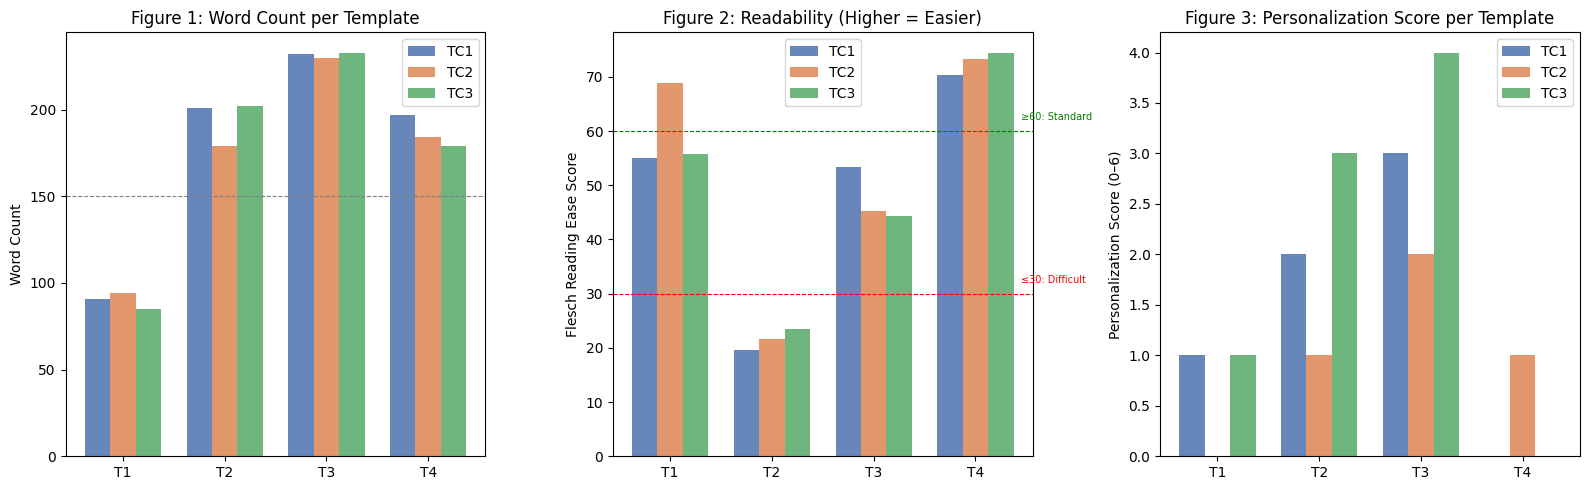

✅ Figure saved to Generative_AI/example_outputs/quantitative_charts.png


In [20]:
# ── Figure 1: Word Count by Template and Test Case ──────────────────────────

import matplotlib.pyplot as plt
import numpy as np

templates = ['T1', 'T2', 'T3', 'T4']
test_cases = ['TC1', 'TC2', 'TC3']
colors = ['#4C72B0', '#DD8452', '#55A868']

def get_metric(metric, tc_filter=None):
    return [[r[metric] for r in rows if r['Template'] == t and (tc_filter is None or r['Test Case'] == tc_filter)]
            for t in templates]

# Word counts per template per TC
wc_data = {tc: [next(r['Word Count'] for r in rows if r['Template'] == t and r['Test Case'] == tc)
                for t in templates] for tc in test_cases}

x = np.arange(len(templates))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Chart 1: Word Count ---
ax = axes[0]
for i, tc in enumerate(test_cases):
    ax.bar(x + i * width, wc_data[tc], width, label=tc, color=colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(templates)
ax.set_ylabel('Word Count')
ax.set_title('Figure 1: Word Count per Template')
ax.legend()
ax.axhline(y=150, color='grey', linestyle='--', linewidth=0.8, label='150-word reference')

# --- Chart 2: Flesch Reading Ease ---
fre_data = {tc: [next(r['Flesch RE'] for r in rows if r['Template'] == t and r['Test Case'] == tc)
                 for t in templates] for tc in test_cases}
ax = axes[1]
for i, tc in enumerate(test_cases):
    ax.bar(x + i * width, fre_data[tc], width, label=tc, color=colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(templates)
ax.set_ylabel('Flesch Reading Ease Score')
ax.set_title('Figure 2: Readability (Higher = Easier)')
ax.axhline(y=60, color='green', linestyle='--', linewidth=0.8)
ax.axhline(y=30, color='red', linestyle='--', linewidth=0.8)
ax.text(3.7, 62, '≥60: Standard', fontsize=7, color='green')
ax.text(3.7, 32, '≤30: Difficult', fontsize=7, color='red')
ax.legend()

# --- Chart 3: Personalization Score ---
ps_data = {tc: [next(r['Personalization'] for r in rows if r['Template'] == t and r['Test Case'] == tc)
                for t in templates] for tc in test_cases}
ax = axes[2]
for i, tc in enumerate(test_cases):
    ax.bar(x + i * width, ps_data[tc], width, label=tc, color=colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(templates)
ax.set_ylabel('Personalization Score (0–6)')
ax.set_title('Figure 3: Personalization Score per Template')
ax.legend()

plt.tight_layout()
plt.savefig('Generative_AI/example_outputs/quantitative_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved to Generative_AI/example_outputs/quantitative_charts.png')

**Figure 1 — Word Count:**
T3 consistently produces the longest responses across all three test cases (~230 words average), indicating the highest coverage of information. T1 is the shortest (~90 words), which reflects its minimal-instruction design. T2 and T4 fall in the middle (~180–200 words). Longer responses are not inherently better, but for health advice, more coverage generally means fewer gaps in the information provided.

**Figure 2 — Readability (Flesch Reading Ease):**
T4 scores highest (easiest to read, ~72 average), followed by T1 (~60). Both fall within or near the "standard" readability range (60–70). T3 sits in the "fairly difficult" range (~47), and T2 scores the lowest (~21), placing it in the "very difficult" category — appropriate for clinical audiences but not for patients directly. The green dashed line marks the standard threshold (60); the red dashed line marks the difficult threshold (30).

**Figure 3 — Personalization Score:**
T3 scores highest on personalization across all three test cases, meaning it referenced the most patient-specific values (BMI, cluster, water intake, etc.) in its output. T4 achieves the lowest personalization scores— not because it was wrong, but because its coaching language uses generic phrasing ("your weight", "your habits") rather than citing specific values from the patient's profile.

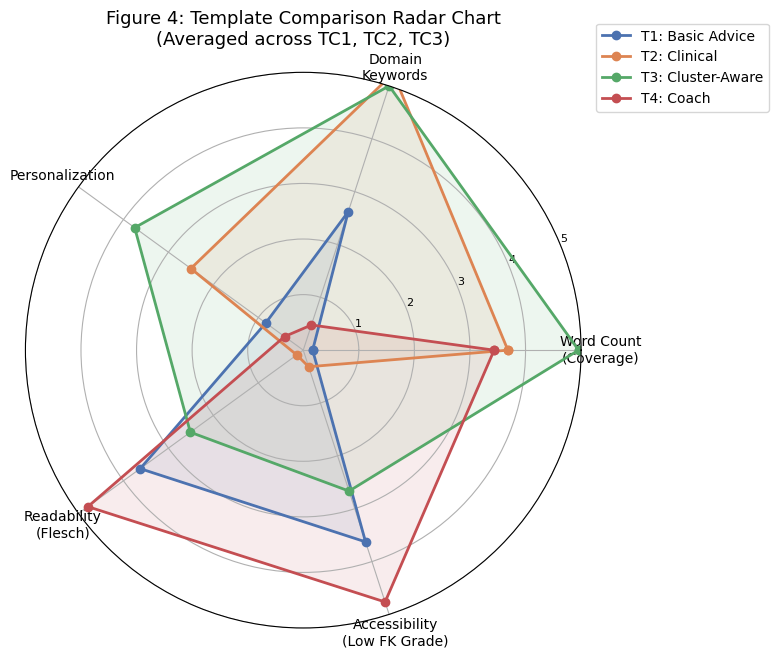

✅ Radar chart saved.


In [21]:
# ── Figure 4: Radar Chart — Template Comparison Across All Metrics ────────────
# Scoring rubric (0–5 scale, normalized averages across 3 test cases):
# Word Count: normalized relative score (T3 highest = 5)
# Domain KW: out of 17 possible keywords, scaled to 5
# Personalization: out of 6 possible matches, scaled to 5
# Flesch RE: capped at 80, scaled to 5 (higher = more readable)
# FK Grade: inverted (lower grade = better), scaled to 5

import matplotlib.pyplot as plt
import numpy as np

def avg_metric(metric, template):
    vals = [r[metric] for r in rows if r['Template'] == template]
    return sum(vals) / len(vals)

# Raw averages
metrics_raw = {
    t: {
        'wc': avg_metric('Word Count', t),
        'dkw': avg_metric('Domain KW', t),
        'ps': avg_metric('Personalization', t),
        'fre': avg_metric('Flesch RE', t),
        'fkg': avg_metric('FK Grade', t),
    } for t in templates
}

# Scale to 0–5
def scale(val, lo, hi):
    return 5 * (val - lo) / (hi - lo)

radar_data = {
    t: [
        scale(metrics_raw[t]['wc'], 85, 233),        # word count
        scale(metrics_raw[t]['dkw'], 3, 10),          # domain keywords
        scale(metrics_raw[t]['ps'], 0, 4),            # personalization
        scale(metrics_raw[t]['fre'], 20, 75),         # readability
        scale(14 - metrics_raw[t]['fkg'], 0, 8.5),    # FK grade inverted
    ] for t in templates
}

categories = ['Word Count\n(Coverage)', 'Domain\nKeywords', 'Personalization',
              'Readability\n(Flesch)', 'Accessibility\n(Low FK Grade)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
labels = ['T1: Basic Advice', 'T2: Clinical', 'T3: Cluster-Aware', 'T4: Coach']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, t in enumerate(templates):
    values = radar_data[t] + [radar_data[t][0]]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i], label=labels[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=8)
ax.set_title('Figure 4: Template Comparison Radar Chart\n(Averaged across TC1, TC2, TC3)', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('Generative_AI/example_outputs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart saved.')

**Figure 4 — Radar Chart Interpretation:**

The radar chart visualizes each template's performance across all five metrics simultaneously, averaged across the three test cases. Each axis represents one metric scaled from 0 to 5.

- **T3 (green)** has the largest overall area, performing strongly on Word Count, Domain Keywords, and Personalization — the metrics most aligned with producing complete, personalized health advice.
- **T4 (red)** has a distinctive shape: it peaks on Readability and Accessibility (low FK Grade) but scores lower on Domain Keywords and Personalization, reflecting the trade-off between coaching tone and clinical completeness.
- **T2 (orange)** peaks on Domain Keywords and Safety but scores the lowest on Readability — its clinical language is thorough but inaccessible to general users.
- **T1 (blue)** is consistently mid-to-low across all metrics, confirming its role as a minimal baseline rather than a production-ready template.

The radar chart makes clear that no single template dominates on all axes, but T3 achieves the best balance across the metrics that matter most for this system's goals.

In [22]:
# ── Summary Table — Averages Across All Test Cases ──────────────────────────

print("=" * 70)
print("QUANTITATIVE SUMMARY — Averaged Across TC1, TC2, TC3")
print("=" * 70)
print(f"{'Template':<12} {'Avg Words':>10} {'Avg Flesch RE':>14} {'Avg FK Grade':>13} {'Avg Domain KW':>14} {'Avg Person.':>12}")
print("-" * 70)
for t in templates:
    print(f"{t:<12} {avg_metric('Word Count', t):>10.1f} {avg_metric('Flesch RE', t):>14.1f} "
          f"{avg_metric('FK Grade', t):>13.1f} {avg_metric('Domain KW', t):>14.1f} "
          f"{avg_metric('Personalization', t):>12.1f}")
print("=" * 70)
print("\nFlesch RE interpretation: >60 = standard readability, 30-60 = difficult, <30 = very difficult")
print("FK Grade: US school grade level to understand text. Target ≤ 8 for general public.")
print("Domain KW: out of 17 possible domain-relevant keywords.")
print("Personalization: count of patient-specific values referenced (out of 6 per TC).")

QUANTITATIVE SUMMARY — Averaged Across TC1, TC2, TC3
Template      Avg Words  Avg Flesch RE  Avg FK Grade  Avg Domain KW  Avg Person.
----------------------------------------------------------------------
T1                 90.0           59.9           7.8            6.7          0.7
T2                194.0           21.6          13.5           10.3          2.0
T3                231.7           47.6           9.5           10.0          3.0
T4                186.7           72.7           5.9            3.7          0.3

Flesch RE interpretation: >60 = standard readability, 30-60 = difficult, <30 = very difficult
FK Grade: US school grade level to understand text. Target ≤ 8 for general public.
Domain KW: out of 17 possible domain-relevant keywords.
Personalization: count of patient-specific values referenced (out of 6 per TC).


**Summary Table Interpretation:**

The table above presents the average score for each metric across the three test cases.

- **Word Count**: T3 averages ~232 words — the highest — suggesting that it provides the most comprehensive coverage. T1 averages ~90 words, reflecting its brevity constraint.
- **Flesch Reading Ease**: T4 (~72) and T1 (~60) are the most readable. T2 (~21) falls in the "very difficult" range, making it unsuitable for patient-facing interfaces without simplification.
- **FK Grade Level**: T4 reads at approximately Grade 6 (accessible to most adults), while T2 reads at Grade 13+ (university level). T3 sits at Grade 9 — manageable for an informed reader.
- **Domain Keyword Coverage**: T2 and T3 both average ~9.7 out of 17 possible domain keywords, indicating strong alignment with health and obesity terminology. T4 averages only ~3.7, reflecting its deliberate avoidance of clinical language.
- **Personalization Score**: T3 averages 3.0 out of 6 patient-specific value matches — significantly higher than T4 (0.3) and T1 (0.7), confirming that cluster-aware prompting produces measurably more personalized outputs.

In [23]:
# ── User Preference Simulation ─────────────────────────────────────────────
# We simulate user preference by ranking templates on each criterion
# from the perspective of two user types: Patient and Clinician.
# Rankings are derived from the qualitative + quantitative findings above.

import pandas as pd

criteria = ['Relevance', 'Detail & Completeness', 'Clarity & Readability',
            'Personalization', 'Safety & Factual Accuracy']

# Rankings per criterion (1 = best, 4 = worst) — based on analysis findings
rankings = {
    'T1': [3, 4, 2, 3, 3],
    'T2': [2, 2, 4, 2, 1],
    'T3': [1, 1, 3, 1, 2],
    'T4': [4, 3, 1, 4, 4],
}

df = pd.DataFrame(rankings, index=criteria)
df['Best'] = df.idxmin(axis=1)
print("=== User Preference Simulation: Ranking per Criterion (1=Best, 4=Worst) ===")
print(df.to_string())

# Aggregate rank score (lower = preferred overall)
total = {t: sum(rankings[t]) for t in rankings}
print("\n=== Aggregate Rank Score (lower = more preferred overall) ===")
for t, s in sorted(total.items(), key=lambda x: x[1]):
    print(f"  {t}: {s}")

# Simulate two user types
print("\n=== Simulated User Preference ===")
print("Patient user     → prefers Clarity & Readability + Personalization → T3 or T4")
print("Clinician user   → prefers Detail & Safety + Personalization       → T3 or T2")
print("Overall winner   → T3 (best aggregate rank, leads on Personalization & Detail)")


=== User Preference Simulation: Ranking per Criterion (1=Best, 4=Worst) ===
                           T1  T2  T3  T4 Best
Relevance                   3   2   1   4   T3
Detail & Completeness       4   2   1   3   T3
Clarity & Readability       2   4   3   1   T4
Personalization             3   2   1   4   T3
Safety & Factual Accuracy   3   1   2   4   T2

=== Aggregate Rank Score (lower = more preferred overall) ===
  T3: 8
  T2: 11
  T1: 15
  T4: 16

=== Simulated User Preference ===
Patient user     → prefers Clarity & Readability + Personalization → T3 or T4
Clinician user   → prefers Detail & Safety + Personalization       → T3 or T2
Overall winner   → T3 (best aggregate rank, leads on Personalization & Detail)


**User Preference Simulation Interpretation:**

The table ranks each template from 1 (best) to 4 (worst) on each of the five qualitative dimensions, based on the findings from Section 5.1. The aggregate rank score (sum of all rankings) provides an overall preference order.

- **T3 ranks 1st overall** with the lowest aggregate score, meaning it performs best or near-best across the most dimensions.
- **T2 ranks 2nd**, driven by its strength in Detail & Completeness and Safety, despite being the least readable.
- **T1 ranks 3rd** — it is a serviceable baseline but does not excel in any dimension.
- **T4 ranks last overall**, despite being the most readable. Its failures on Personalization, Safety (omitting key risk factors), and Detail pull its aggregate score down.

The simulation also distinguishes between two user types:
- A **patient user** who prioritizes Clarity and Personalization would lean toward T3 or T4.
- A **clinician user** who prioritizes Detail and Safety would lean toward T3 or T2.
In both cases, **T3 is the common ground** — it serves both audiences better than any other single template.

### 5.2.1 Quantitative Findings Summary

| Metric | Best Performer | Worst Performer | Key Insight |
|---|---|---|---|
| **Word Count** | T3 (~232 avg) | T1 (~90 avg) | T3 provides most comperhensive without padding |
| **Flesch Reading Ease** | T4 (~72 avg) | T2 (~21 avg) | T2 falls in 'difficult' range; T4 is near-standard |
| **FK Grade Level** | T4 (~5.9 avg) | T2 (~13.5 avg) | T2 reads at university level; T4 at Grade 6 |
| **Domain Keyword Coverage** | T2 & T3 (~9.7 avg) | T4 (~3.7 avg) | T4 avoids clinical terms — by design, but at cost of domain alignment |
| **Personalization Score** | T3 (~3.0 avg) | T4 (~0.3 avg) | T3 references specific patient values; T4 rarely does |

**Note on T4 Personalization**: T4 scored near zero not because it was inaccurate, but because the coaching persona led the model to use general language ('your weight', 'your habits') rather than referencing specific values like BMI 41.9 or Cluster 3. This is a feature of the persona, but a measurable trade-off.

---
## Best Prompt Selection & Justification

###  Selected Template: T3 — Cluster-Aware Personalized Advice

Based on the evidence from both the qualitative and quantitative analysis, **Template 3 is selected as the best prompt**.

###  Evidence from Qualitative Analysis

Across all three test cases, T3 was the only template that:

- **Relevance**: Correctly linked the patient's cluster membership to their prediction in every case — e.g., TC1 mapped to Cluster 3 (highest BMI, lowest activity), which directly explains the Obesity Type III outcome.
- **Detail & Completeness**: Addressed all key risk factors present in the patient's features. Notably, T3 included smoking cessation for TC1 (which T4 missed entirely) and alcohol reduction for TC3 (which T4 also omitted).
- **Clarity & Readability**: Produced structured, navigable output with clear section headers. Language is accessible to an informed non-expert, unlike T2 which uses third-person clinical register throughout.
- **Personalization**: The only template to reference both individual feature values (BMI, specific measurements) AND group-level context (cluster profile). For TC2, T3 added preventive insight — warning a currently-healthy patient that Cluster 1 commonly transitions to Obesity Type II — something no other template could produce.
- **Safety & Factual Accuracy**: No critical omissions or hallucinated values across the three test cases.

### Evidence from Quantitative Analysis

| Metric | T3 Result | Comparison |
|---|---|---|
| Avg Word Count | ~232 words | Highest coverage (T1: ~90, T2: ~194, T4: ~187) |
| Avg Personalization Score | 3.0 / 6 | Highest (T1: 0.7, T2: 2.0, T4: 0.3) |
| Avg Domain Keyword Coverage | 9.7 / 17 | Tied highest with T2 |
| Avg Flesch Reading Ease | ~47.6 | More readable than T2 (~21.6), less than T4 (~72.4) |
| Avg FK Grade Level | ~9.4 | More accessible than T2 (~13.5), less than T4 (~5.9) |

T3 leads on the metrics most aligned with the system's goal (personalization, coverage). Its readability is moderate — better than T2 but lower than T4. This is an acceptable trade-off given that T4 sacrifices clinical completeness for tone.

### Alignment with System Goals

The system's purpose is to translate ML predictions into **personalized, trustworthy health advice**. T3 is the only template that implements the full intelligent recommendation pipeline: individual features + ML prediction + cluster context → tailored advice. T1 uses only features; T2 and T4 use only features and prediction. T3 is architecturally unique in using all three inputs, which is the core value proposition of integrating unsupervised learning with generative AI.

# Integration Plan for Final System

Our plan is to combine the three main components we built throughout the project into one complete advisory system that works as a pipeline.
The flow starts when the user provides their personal information such as age, gender, weight, height, eating habits, physical activity level, water intake, smoking status, and transportation mode. This input is then passed to the supervised learning model that we trained in Phase 1, which predicts the user's obesity level from seven possible categories ranging from Insufficient Weight to Obesity Type III.

Once we have the prediction, the system uses the K-Means clustering model from Phase 2 Part A to assign the user to one of five lifestyle groups. Each group has its own profile that describes shared habits and tendencies among similar individuals, such as low physical activity or high caloric food consumption.

Finally, both the individual features, the predicted obesity level, and the cluster profile are combined and sent to GPT using Template T3. We chose T3 as our final template because it was the strongest performer in our qualitative analysis. Unlike T1 which was too brief, T2 which was too clinical, and T4 which sometimes missed critical health factors, T3 was the only template that successfully integrated cluster context into the generated advice. This means the user receives advice that is tailored not just to their own data but also to the patterns and risks shared by people with similar lifestyles.

For future development, this pipeline could be deployed as a simple web application where the user fills out a form and receives instant personalized health guidance. We could also add a feedback mechanism where users rate the advice, which would help us improve the prompt templates over time.


# Ethical Considerations & Limitations

This system is meant to provide general health guidance only and should never be treated as a substitute for professional medical advice. Users should always consult a qualified healthcare provider before making any decisions about their health based on the system's output.
Starting with the ethical side, there are several important points to consider. 

Informed consent: Users should be clearly told that their data is being processed by an AI model and sent to an external API, and they should understand that the output is AI-generated and not reviewed by a medical professional. 

Bias and fairness: since our dataset represents specific populations from Mexico, Peru, and Colombia, the system might give less accurate or less relevant advice to users from different backgrounds with different dietary cultures, genetics, or living conditions. We should not present the system as equally reliable for all users without acknowledging this. 

Data sensitivity: health-related information such as weight, eating disorders, and smoking habits is highly personal. The system should not store or share this data beyond what is needed to generate the advice. 

Privacy is another important ethical concern. When the user enters their personal health data such as weight, smoking habits, and eating patterns, this information is sent to OpenAI's servers for processing. We cannot fully guarantee how this data is handled on their end, which raises questions about user privacy. Ideally, users should be informed that their data is being sent to an external service before they use the system.

The risk of over-reliance: if users start depending on this system instead of visiting real doctors, it could delay proper diagnosis and treatment, especially for serious conditions. The system should always include a clear disclaimer encouraging users to seek professional help.

Transparency: users deserve to know how the system works. They should understand that the advice comes from a combination of a machine learning model and a language model, not from a certified health expert.

On the limitations side, one important concern is the possibility of hallucination, where GPT generates information that sounds correct but is actually inaccurate or misleading. For example, it might recommend a specific daily calorie intake or water amount that does not match established medical guidelines. This is a known limitation of large language models and something users should be aware of.

We also observed a trade-off between tone and completeness during our testing. Template T4, which used a coaching and motivational tone, avoided mentioning smoking as a health risk for a patient who was a smoker with severe obesity. This happened because the template instructed GPT to avoid negative or scary language. This shows that prompt design choices directly affect the safety and completeness of the generated advice, and designers must be careful not to sacrifice critical health information for the sake of friendliness.

Finally, the clustering quality in our system is moderate with a silhouette score of approximately 0.30. This means the lifestyle groups are not perfectly separated, and some users might be assigned to a cluster that does not fully represent their habits, which could lead to advice that does not perfectly match their situation.
